In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('HRDataset_v14.csv', encoding='latin1')

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ï»¿Employee_Name            311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [4]:
taxa_desligamento = df['Termd'].mean() * 100
print(f"TAXA DE DESLIGAMENTO GERAL \n{taxa_desligamento:.1f}% dos funcionários se desligaram\n")

TAXA DE DESLIGAMENTO GERAL 
33.4% dos funcionários se desligaram



In [5]:
print("DESLIGAMENTO POR DEPARTAMENTO")
dept_turnover = df.groupby('Department')['Termd'].agg(['mean', 'count']).sort_values('mean', ascending=False)
dept_turnover['mean'] = dept_turnover['mean'] * 100
print(dept_turnover.to_string())

DESLIGAMENTO POR DEPARTAMENTO
                           mean  count
Department                            
Production            39.712919    209
Software Engineering  36.363636     11
Admin Offices         22.222222      9
IT/IS                 20.000000     50
Sales                 16.129032     31
Executive Office       0.000000      1


In [6]:
print("DESLIGAMENTO POR PERFORMANCE ")
perf_turnover = df.groupby('PerformanceScore')['Termd'].mean() * 100
print(perf_turnover.sort_values(ascending=False))

DESLIGAMENTO POR PERFORMANCE 
PerformanceScore
Needs Improvement    55.555556
PIP                  38.461538
Fully Meets          33.333333
Exceeds              21.621622
Name: Termd, dtype: float64


In [7]:
print("SATISFAÇÃO E ENGAJAMENTO MÉDIO")
print(f"Engajamento médio: {df['EngagementSurvey'].mean():.2f}")
print(f"Satisfação média: {df['EmpSatisfaction'].mean():.2f}")

SATISFAÇÃO E ENGAJAMENTO MÉDIO
Engajamento médio: 4.11
Satisfação média: 3.89


In [8]:
print("COMPARAÇÃO: QUEM FICOU vs QUEM SAIU")
print("Média de engajamento:")
print(df.groupby('Termd')['EngagementSurvey'].mean())
print("\nMédia de satisfação:")
print(df.groupby('Termd')['EmpSatisfaction'].mean())

COMPARAÇÃO: QUEM FICOU vs QUEM SAIU
Média de engajamento:
Termd
0    4.119807
1    4.090481
Name: EngagementSurvey, dtype: float64

Média de satisfação:
Termd
0    3.893720
1    3.884615
Name: EmpSatisfaction, dtype: float64


In [9]:
print(f"SALÁRIO MÉDIO")
print(f"Ficaram: ${df[df['Termd']==0]['Salary'].mean():.0f}")
print(f"Sairam: ${df[df['Termd']==1]['Salary'].mean():.0f}")

SALÁRIO MÉDIO
Ficaram: $70694
Sairam: $65690


In [10]:
df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

In [11]:
df['tenure_days'] = np.where(df['Termd']==1, 
                              (df['DateofTermination'] - df['DateofHire']).dt.days,
                              (pd.Timestamp.now() - df['DateofHire']).dt.days)
df['tenure_years'] = df['tenure_days'] / 365

print(f"TEMPO DE CASA")
print(f"Média de quem ficou: {df[df['Termd']==0]['tenure_years'].mean():.1f}")
print(f"Média de quem saiu: {df[df['Termd']==1]['tenure_years'].mean():.1f}")

TEMPO DE CASA
Média de quem ficou: 12.7
Média de quem saiu: 3.5


In [12]:
print("PRINCIPAIS MOTIVOS DE DESLIGAMENTO")
motivos = df[df['Termd']==1]['TermReason'].value_counts()
print(motivos.head(5))

PRINCIPAIS MOTIVOS DE DESLIGAMENTO
TermReason
Another position    20
unhappy             14
more money          11
career change        9
hours                8
Name: count, dtype: int64


In [13]:
def calcular_risco_turnover(row):
    risco = 0
    
    
    if row['Department'] == 'Production':
        risco += 25
    

    if row['PerformanceScore'] in ['Needs Improvement', 'PIP']:
        risco += 20
    
  
    if row['tenure_years'] < 4:
        risco += 15
    
    
    if row['DaysLateLast30'] > 2 or row['Absences'] > 5:
        risco += 10
    
    return min(risco, 100)

df['risco_turnover'] = df.apply(calcular_risco_turnover, axis=1)


df['nivel_risco'] = pd.cut(df['risco_turnover'], 
                           bins=[0, 30, 60, 100], 
                           labels=['Baixo', 'Médio', 'Alto'])


print("VALIDAÇÃO DO SCORE DE RISCO ")
print(df.groupby('nivel_risco')['Termd'].mean() * 100)

print("\nCORRELAÇÃO COM TURNOVER REAL")
from scipy.stats import pointbiserialr
corr, p = pointbiserialr(df['risco_turnover'], df['Termd'])
print(f"Correlação: {corr:.3f} (p={p:.2e})")

VALIDAÇÃO DO SCORE DE RISCO 
nivel_risco
Baixo     36.440678
Médio    100.000000
Alto            NaN
Name: Termd, dtype: float64

CORRELAÇÃO COM TURNOVER REAL
Correlação: 0.519 (p=7.49e-23)


C:\Users\joyce\AppData\Local\Temp\ipykernel_11724\1822871624.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('nivel_risco')['Termd'].mean() * 100)


In [14]:
df['nivel_risco_v2'] = pd.cut(df['risco_turnover'], 
                              bins=[0, 20, 40, 60, 100], 
                              labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto'])

print("NOVA DISTRIBUIÇÃO DOS NÍVEIS ")
print(df['nivel_risco_v2'].value_counts())

print("\nTURNOVER POR NÍVEL DE RISCO (V2)")
print(df.groupby('nivel_risco_v2', observed=False)['Termd'].mean() * 100)

alto_risco = df[(df['nivel_risco_v2'] == 'Alto') & (df['Termd'] == 0)]
print(f"\nFUNCIONÁRIOS ATIVOS DE ALTO RISCO")
print(f"Quantidade: {len(alto_risco)}")
print(f"Percentual da base ativa: {len(alto_risco)/len(df[df['Termd']==0])*100:.1f}%")


print("\n PERFIL DO FUNCIONÁRIO DE ALTO RISCO")
print(alto_risco[['Department', 'PerformanceScore', 'tenure_years', 'Salary', 'DaysLateLast30']].head(10))

NOVA DISTRIBUIÇÃO DOS NÍVEIS 
nivel_risco_v2
Muito Baixo    166
Baixo           70
Médio            7
Alto             0
Name: count, dtype: int64

TURNOVER POR NÍVEL DE RISCO (V2)
nivel_risco_v2
Muito Baixo     18.072289
Baixo           80.000000
Médio          100.000000
Alto                  NaN
Name: Termd, dtype: float64

FUNCIONÁRIOS ATIVOS DE ALTO RISCO
Quantidade: 0
Percentual da base ativa: 0.0%

 PERFIL DO FUNCIONÁRIO DE ALTO RISCO
Empty DataFrame
Columns: [Department, PerformanceScore, tenure_years, Salary, DaysLateLast30]
Index: []


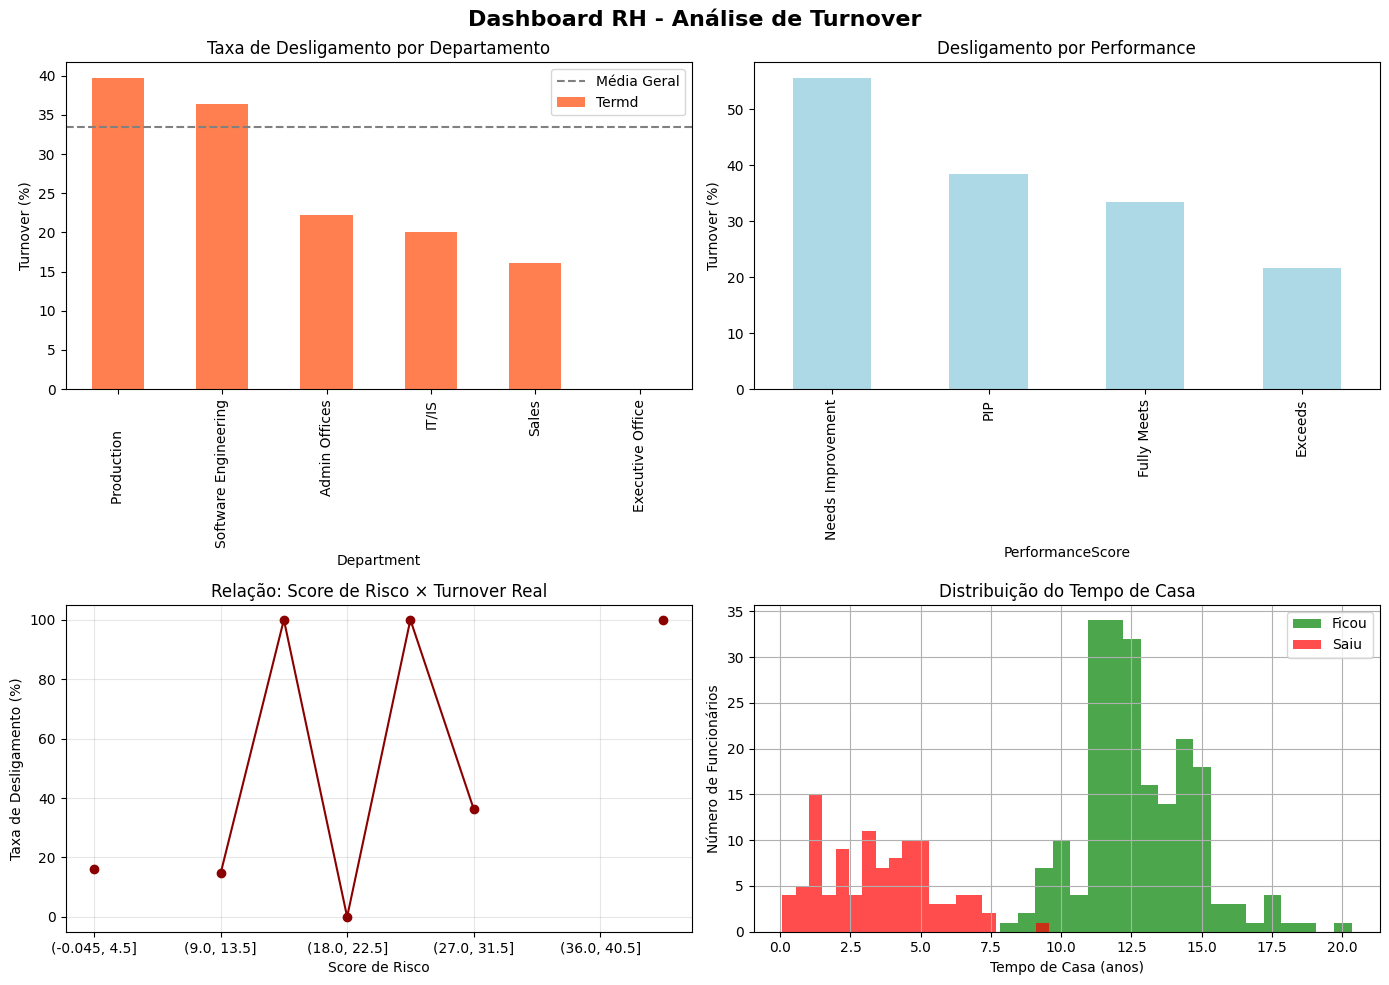

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard RH - Análise de Turnover', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
dept_turnover = df.groupby('Department')['Termd'].mean() * 100
dept_turnover.sort_values(ascending=False).plot(kind='bar', ax=ax1, color='coral')
ax1.set_ylabel('Turnover (%)')
ax1.set_title('Taxa de Desligamento por Departamento')
ax1.axhline(y=df['Termd'].mean()*100, linestyle='--', color='gray', label='Média Geral')
ax1.legend()

ax2 = axes[0, 1]
perf_turnover = df.groupby('PerformanceScore')['Termd'].mean() * 100
perf_turnover.sort_values(ascending=False).plot(kind='bar', ax=ax2, color='lightblue')
ax2.set_ylabel('Turnover (%)')
ax2.set_title('Desligamento por Performance')


ax3 = axes[1, 0]
df['risco_bin'] = pd.cut(df['risco_turnover'], bins=10)
risco_turnover = df.groupby('risco_bin', observed=False)['Termd'].mean() * 100
risco_turnover.plot(kind='line', marker='o', ax=ax3, color='darkred')
ax3.set_xlabel('Score de Risco')
ax3.set_ylabel('Taxa de Desligamento (%)')
ax3.set_title('Relação: Score de Risco × Turnover Real')
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
df[df['Termd']==0]['tenure_years'].hist(bins=20, alpha=0.7, label='Ficou', color='green')
df[df['Termd']==1]['tenure_years'].hist(bins=20, alpha=0.7, label='Saiu', color='red')
ax4.set_xlabel('Tempo de Casa (anos)')
ax4.set_ylabel('Número de Funcionários')
ax4.set_title('Distribuição do Tempo de Casa')
ax4.legend()

plt.tight_layout()
plt.savefig('hr_dashboard_turnover.png', dpi=300, bbox_inches='tight')
plt.show()
